In [6]:
from collections import Counter
import math, random
import matplotlib.pyplot as plt

#### Conditional Probability

In [2]:
def random_kid():
    return random.choice(['boy','girl'])

In [3]:
if __name__ == "__main__":
    both_girls = 0
    older_girl = 0
    either_girl = 0

    random.seed(0)
    for _ in range(10000):
        younger = random_kid()
        older = random_kid()
        if older == "girl":
            older_girl += 1
        if older == "girl" and younger == "girl":
            both_girls += 1
        if older == "girl" or younger == "girl":
            either_girl += 1

    print("P(both | older):", both_girls / older_girl)      # 0.514 ~ 1/2
    print("P(both | either): ", both_girls / either_girl)   # 0.342 ~ 1/3
   

P(both | older): 0.5007089325501317
P(both | either):  0.3311897106109325


#### Continuous Distributions

In [5]:
def uniform_pdf(x):
    return 1 if x >= 0 and x < 1 else 0

def uniform_cdf(x):
    """ returns the probability that a uniform random variable is less than x"""
    if x<0:   return 0
    elif x<1: return x
    else:     return1

#### Normal Distributions

In [8]:
def normal_pdf(x, mu=0, sigma=1):
    sqrt_two_pi = math.sqrt(2*math.pi)
    return (math.exp(-(x-mu)**2 / 2 / sigma ** 2) / (sqrt_two_pi * sigma))

def plot_norm_pdfs(plt):
    xs = [x / 10.0 for x in range(-50,50)]
    plt.plot(xs, [normal_pdf(x,sigma=1) for x in xs],
             '-', label='mu=0, sigma=1')
    plt.plot(xs, [normal_pdf(x, sigma=2) for x in xs],
             '--', label='mu=0, sigma=2')
    plt.plot(xs, [normal_pdf(x, sigma=0.5) for x in xs],
             ':', label='mu=0, sigma=0.5')
    plt.plot(xs, [normal_pdf(x, mu=-1) for x in xs],
             '-.', label='mu=-1, sigma=1')
    plt.legend()
    plt.show()
    

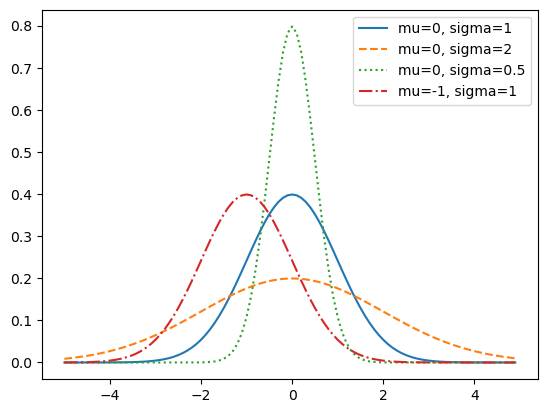

In [9]:
plot_norm_pdfs(plt)

In [10]:
def normal_cdf(x, mu=0, sigma=1):
    return (1+math.erf((x-mu) / math.sqrt(2) / sigma)) / 2

def plot_normal_cdfs(plt):
    xs = [x / 10.0 for x in range(-50, 50)]
    plt.plot(xs,[normal_cdf(x,sigma=1) for x in xs],
             '-',label='mu=0,sigma=1')
    plt.plot(xs,[normal_cdf(x,sigma=2) for x in xs],
             '--',label='mu=0,sigma=2')
    plt.plot(xs,[normal_cdf(x,sigma=0.5) for x in xs],
             ':',label='mu=0,sigma=0.5')
    plt.plot(xs,[normal_cdf(x,mu=-1) for x in xs],
             '-.',label='mu=-1,sigma=1')
    plt.legend(loc=4) # bottom right
    plt.show()

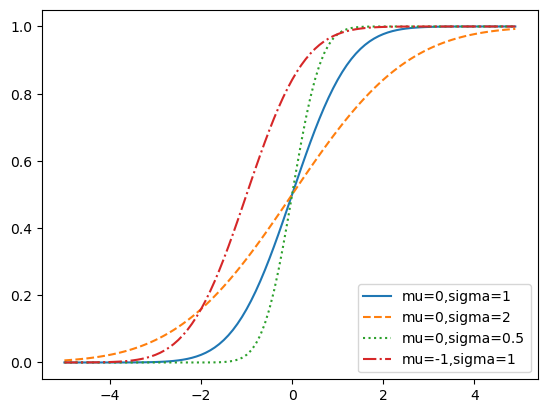

In [11]:
plot_normal_cdfs(plt)

In [13]:
def inverse_normal_cdf(p, mu=0, sigma=1, tolerance=0.00001):
    """ find approximate inverse using binary search """
    if mu != 0 or sigma != 1:
        return mu + sigma * inverse_normal_cdf(p, tolerance = tolerance)
    low_z, low_p = -10.0, 0
    hi_z, hi_p = 10.0, 1
    while hi_z - low_z > tolerance:
        mid_z = (low_z + hi_z) / 2
        mip_p = normal_cdf(midz)
        if mid_p < p:
            low_z, low_p = mid_z, mid_p
        elif mid_p > p:
            hi_z, hi_p = mid_z, mid_p
        else:
            break
    return_mid_z

#### Central Limit Theorem

In [16]:
def bernoulli_trial(p):
    return 1 if random.random() < p else 0

def binomial(p,n):
    return sum(bernoulli_trial(p) for _ in range(n))

def make_hist(p, n, num_points):
    data = [binomial(p,n) for _ in range(num_points)]
    histogram = Counter(data)
    plt.bar([x - 0.4 for x in histogram.keys()],
            [v / num_points for v in histogram.values()],
            0.8, color='0.75')
    mu = p * n
    sigma = math.sqrt(n * p * (1-p))
    xs = range(min(data), max(data) + 1)
    ys = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma)
            for i in xs]
    plt.plot(xs, ys)
    plt.show()

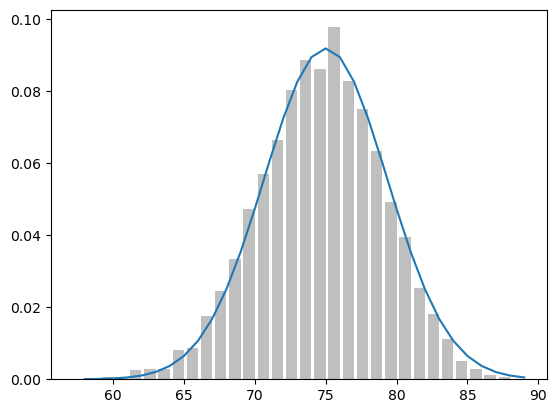

In [17]:
make_hist(0.75,100,10000)